# AI/ML Task 2 – Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing Dataset  
**Models:** Linear Regression · Ridge Regression · Decision Tree Regressor  
**Goal:** Preprocess data, train multiple models, compare performance, and select the best one.

## Step 1: Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
import pickle
import joblib
import os

## Step 2: Load the Dataset

We use scikit-learn's built-in **California Housing Dataset**.  
It contains 20,640 samples with 8 numeric features and a continuous target: **Median House Value** (in $100,000s).

In [17]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    HousePrice  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [19]:
print("Checking for missing values in the dataset:")
print(df.isnull().sum())

Checking for missing values in the dataset:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


## Step 3: Separate Features and Target Variable

- **X** → input features (8 columns)  
- **y** → target variable (`HousePrice`)


In [20]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]#here we are splitting the dataset into training and testing sets, with 80% of the data used for training and 20% for testing. The random_state parameter ensures reproducibility of the results.
print(X.shape, y.shape)
print(X.head())
print()
print(y.head())

(20640, 8) (20640,)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64


## Step 4: Feature Scaling (Critical Step)

Features span very different numeric ranges:
- `MedInc` (median income) → ~0–15  
- `Population` → ~3–35,000  

Without scaling, large-range features dominate the model.  
**StandardScaler** transforms each feature to have **mean = 0** and **std = 1**.


In [21]:
scalling = StandardScaler()
X_scaled = scalling.fit_transform(X)
print(X_scaled)

[[ 2.34476576  0.98214266  0.62855945 ... -0.04959654  1.05254828
  -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 ... -0.09251223  1.04318455
  -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 ... -0.02584253  1.03850269
  -1.33282653]
 ...
 [-1.14259331 -0.92485123 -0.09031802 ... -0.0717345   1.77823747
  -0.8237132 ]
 [-1.05458292 -0.84539315 -0.04021111 ... -0.09122515  1.77823747
  -0.87362627]
 [-0.78012947 -1.00430931 -0.07044252 ... -0.04368215  1.75014627
  -0.83369581]]


## Step 5: Train–Test Split

- **75%** of data → training (model learns from this)  
- **25%** of data → testing (unseen data for evaluation)  
- `random_state=42` ensures reproducibility


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

## Step 6: Train Baseline Models
Linear Regression
Train a Linear Regression model using the training dataset.
Predict house prices for both training and testing data.
Evaluate the model using RMSE and R² Score.
Ridge Regression
Train a Ridge Regression model with regularization.
Regularization helps reduce overfitting by penalizing large coefficients.
Compare its performance with Linear Regression.

In [23]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_r2 = r2_score(y_test, lr_test_pred)
print("Linear Regression")
print("Train RMSE:", lr_train_rmse)
print("Test RMSE :", lr_test_rmse)
print("R² Score :", lr_r2)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_r2 = r2_score(y_test, ridge_test_pred)
print("Ridge Regression")
print("Train RMSE:", ridge_train_rmse)
print("Test RMSE :", ridge_test_rmse)
print("R² Score :", ridge_r2)


Linear Regression
Train RMSE: 0.7214930466501481
Test RMSE : 0.7356145375446769
R² Score : 0.5910509795491351
Ridge Regression
Train RMSE: 0.7214931216287923
Test RMSE : 0.7355913033582134
R² Score : 0.5910768122298602


## Step 7: Detect Overfitting
- Train a Decision Tree Regressor without any constraints.
- Compare Training RMSE and Testing RMSE.
- A significantly lower training error than testing error indicates overfitting.
- This analysis helps determine whether the model memorizes the training data.

In [24]:
# Decision Tree Regression
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print("Decision Tree Regression")
print("Train RMSE :", train_rmse)
print("Test RMSE :", test_rmse)

Decision Tree Regression
Train RMSE : 3.013481908235909e-16
Test RMSE : 0.7276219215908587


## Step 8: Cross-Validation
- Perform 5-Fold Cross-Validation using cross_val_score().
- Split the dataset into five equal parts.
- Train the model on four folds and validate it on the remaining fold.
- Repeat the process five times and calculate the average RMSE.
- Cross-validation provides a more reliable estimate of model performance than a single train-test split.

In [25]:
#Linear Regression
cv_lr = cross_val_score(lr,X_scaled,y,cv=5,scoring="neg_root_mean_squared_error")
print("Average CV RMSE:", -cv_lr.mean())

#Ridge Regression
cv_ridge = cross_val_score(ridge,X_scaled,y,cv=5,scoring="neg_root_mean_squared_error")
print("Average CV RMSE:", -cv_ridge.mean())

#Decision Tree Regression
cv_tree = cross_val_score(tree,X_scaled,y,cv=5,scoring="neg_root_mean_squared_error")
print("Average CV RMSE:", -cv_tree.mean())

Average CV RMSE: 0.7459068363518115
Average CV RMSE: 0.7459006592292845
Average CV RMSE: 0.8957031908951016


## Step 9: Hyperparameter Tuning
- Use GridSearchCV to automatically search for the best hyperparameter combination.
- Tune important Decision Tree parameters such as:
    - max_depth
    - min_samples_split
    - min_samples_leaf
- Select the parameter combination that minimizes validation error.
- This helps reduce overfitting and improve generalization.

In [26]:
param_grid = {"max_depth":[3,5,7,10],"min_samples_split":[2,5,10],"min_samples_leaf":[1,2,4]}
grid = GridSearchCV(DecisionTreeRegressor(random_state=42),param_grid,cv=5,scoring="neg_root_mean_squared_error",n_jobs=-1)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


## Step 10: Evaluate the Optimized Model
- Retrieve the best model returned by GridSearchCV.
- Predict house prices on the test dataset.
- Calculate:
    - Root Mean Squared Error (RMSE)
    - R² Score
- Compare these metrics with the baseline models.

In [27]:
best_tree = grid.best_estimator_
prediction = best_tree.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)
print("RMSE :", rmse)
print("R² :", r2)

RMSE : 0.6327777233277084
R² : 0.6973986029566237


## Step 11: Cross-Validate the Optimized Model
- Perform 5-Fold Cross-Validation on the tuned Decision Tree model.
- Compute the average cross-validation RMSE.
- This confirms whether the optimized model performs consistently across different data splits.

In [28]:
cv_best = cross_val_score(best_tree,X_scaled,y,cv=5,scoring="neg_root_mean_squared_error")
print("Average CV RMSE:", -cv_best.mean())

Average CV RMSE: 0.7641804639063036


## Step 12: Model Comparison
- Create a comparison table containing:
    - Model Name
    - Test RMSE
    - R² Score
    - Cross-Validation RMSE
- Compare Linear Regression, Ridge Regression, and the Tuned Decision Tree.
- Identify the model with the best balance between accuracy and generalization.

In [29]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression","Decision Tree (Tuned)"],
    "Test RMSE":[lr_test_rmse,ridge_test_rmse,rmse],
    "R² Score":[lr_r2,ridge_r2,r2],
    "Cross Validation RMSE":[-cv_lr.mean(),-cv_ridge.mean(),-cv_best.mean()]})
results

,Model,Test RMSE,R² Score,Cross Validation RMSE
0,Linear Regression,0.735615,0.591051,0.745907
1,Ridge Regression,0.735591,0.591077,0.745901
2,Decision Tree (Tuned),0.632778,0.697399,0.764180


## Step 13: Visualization
# RMSE Comparison
- Plot a bar chart comparing the RMSE values of all models.
- Lower RMSE indicates better prediction accuracy.

# R² Score Comparison
- Plot a bar chart comparing the R² scores of all models.
- Higher R² values indicate better explanatory power.

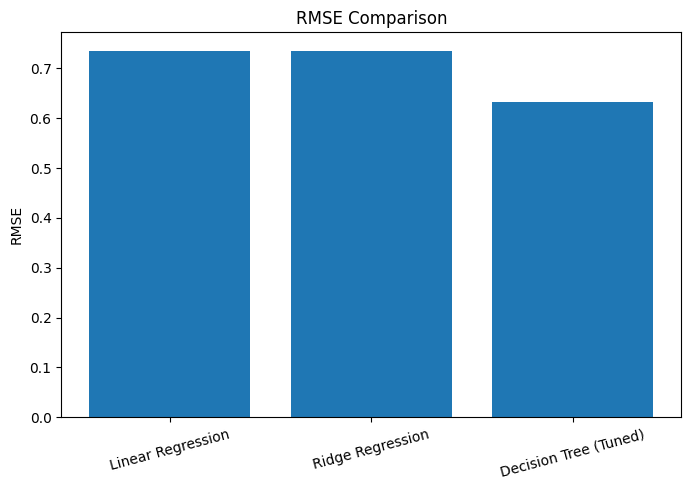

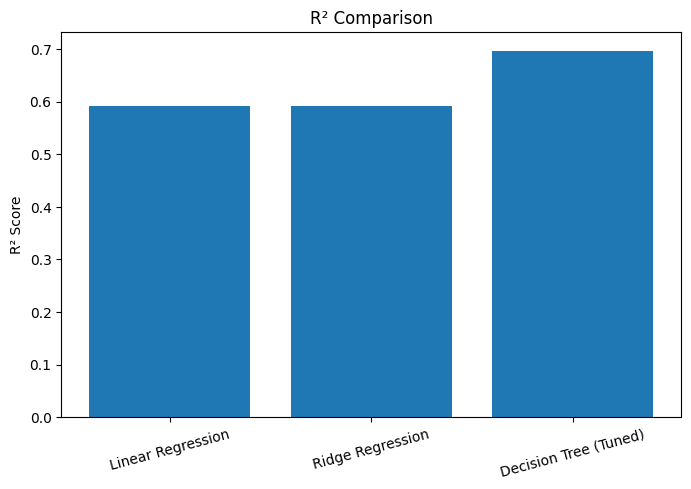

In [30]:
#RMSE comparison
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Test RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

#r2 score comparison
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R² Score"])
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.show()

In [31]:
print(results)

                   Model  Test RMSE  R² Score  Cross Validation RMSE
0      Linear Regression   0.735615  0.591051               0.745907
1       Ridge Regression   0.735591  0.591077               0.745901
2  Decision Tree (Tuned)   0.632778  0.697399               0.764180


## Step 14: Save the Trained Model

- Save the best-performing trained model using the **Joblib** library.
- Saving the model allows it to be reused later without retraining.
- The saved model can be loaded for predictions in deployment or future applications.

In [32]:
# Save the best tuned model
joblib.dump(best_tree, "best_decision_tree_model.joblib")
print("Model saved successfully as 'best_decision_tree_model.joblib'")

# Check if the model file exists
if os.path.exists("best_decision_tree_model.joblib"):
    print("Model file exists.")
else:
    print("Model file not found.")

# Load the saved model
loaded_model = joblib.load("best_decision_tree_model.joblib")
print("Model loaded successfully!")

#make predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test)
print("First 10 Predictions:")
print(loaded_predictions[:10])

Model saved successfully as 'best_decision_tree_model.joblib'
Model file exists.
Model loaded successfully!
First 10 Predictions:
[0.54222206 0.77373158 5.00001    2.62121965 2.07215942 1.45924138
 2.36418182 1.69108411 2.53180289 4.9486937 ]


## Summary & Conclusions

| Step | Action |
|---|---|
| 1 | Imported all required libraries for preprocessing, model training, validation, and evaluation |
| 2 | Loaded the California Housing Dataset and prepared features and target variable |
| 3 | Explored the dataset and verified data quality (missing values, statistics, and structure) |
| 4 | Applied **StandardScaler** to standardize feature values |
| 5 | Split the dataset into **80% training** and **20% testing** sets |
| 6 | Trained baseline models: **Linear Regression**, **Ridge Regression**, and **Decision Tree Regression** |
| 7 | Detected **overfitting** by comparing training and testing RMSE of the Decision Tree model |
| 8 | Performed **5-Fold Cross-Validation** to obtain reliable model performance estimates |
| 9 | Tuned the Decision Tree using **GridSearchCV** to identify the optimal hyperparameters |
| 10 | Evaluated the optimized model using **RMSE** and **R² Score** on the test dataset |
| 11 | Compared all models using Test RMSE, Cross-Validation RMSE, and R² Score |
| 12 | Visualized model performance using comparison charts |
| 13 | Saved the best-performing trained model and scaler using **Joblib** for future deployment |

### Key Takeaways

- **Cross-Validation** provides a more reliable estimate of model performance than a single train-test split.
- **Overfitting** occurs when a model performs exceptionally well on training data but poorly on unseen data.
- **GridSearchCV** systematically searches for the best hyperparameter combination, improving model generalization.
- Restricting Decision Tree parameters such as **`max_depth`**, **`min_samples_split`**, and **`min_samples_leaf`** helps control overfitting.
- **RMSE** measures prediction error, while **R² Score** indicates how well the model explains the variance in the target variable.
- The final model is selected based on its ability to achieve **low RMSE**, **high R² Score**, and **consistent Cross-Validation performance**, ensuring better reliability on unseen data.
- Saving the trained model with **Joblib** enables quick loading and deployment without retraining.